# Insights from training

This notebook looks at some of the results obtained from training.

## 1. Fixed angles performance on SV

The fixed angles are expected to perform well on random regular graph but we also used them on other graph settings. Here we take a look at the results. The notebook does the following.

1. Load all fixed-angle results (with and without re-optimization) for state vector simulations.
2. Plot their performance in terms of approximation ratio.

In [1]:
import glob
import json

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from qaoa_parameter_setting.utils.graph_utils import maxcut_approximation_ratio

In [2]:
folders = ["random_regular", "erdos_renyi", "line_to_full"]

In [32]:
sv_fa_opt = {}
missing = set()

for folder in folders:
    sv_fa_opt[folder] = dict()
    for file_name in glob.glob(f"data/training/{folder}/*.json"):
        if "MC_FA_SV_opt" in file_name: 
            with open(file_name, "r") as fin:
                data = json.load(fin)

            graph = data["args"]["input"].split("/")[-1]
            graph_name = graph.replace(".json", "")
            
            try:
                with open(f"data/minmax_cuts/{folder}/{graph_name}_maxmin_cut.json", "r") as fin:
                    minmax = json.load(fin)
            except FileNotFoundError:
                missing.add(graph)
                continue

            min_c, max_c, sum_w = minmax["min_cut"], minmax["max_cut"], minmax["sum_of_weights"]
            
            approx_ratio = maxcut_approximation_ratio(min_c, max_c, sum_w, data["1"]["energy"])

            depth = len(data["1"]["optimized_qaoa_angles"]) // 2

            if depth == 1:
                continue
            
            if depth not in sv_fa_opt[folder]:
                sv_fa_opt[folder][depth] = dict()
            
            sv_fa_opt[folder][depth][graph] = {
                "angles": data["1"]["optimized_qaoa_angles"],
                "energy": data["1"]["energy"],
                "approx_ratio": approx_ratio,
            }

If minimum and maximum cut values are missing we need to compute them. Below we show how to do this.

In [33]:
sv_fa_no_opt = {}
missing = set()
skipped = set()

for folder in folders:
    sv_fa_no_opt[folder] = dict()
    for file_name in glob.glob(f"data/training/{folder}/*.json"):
        if "MC_FA_SV_noOpt" in file_name: 
            with open(file_name, "r") as fin:
                data = json.load(fin)

            graph = data["args"]["input"].split("/")[-1]
            graph_name = graph.replace(".json", "")
            
            try:
                with open(f"data/minmax_cuts/{folder}/{graph_name}_maxmin_cut.json", "r") as fin:
                    minmax = json.load(fin)
            except FileNotFoundError:
                missing.add(graph)
                continue

            min_c, max_c, sum_w = minmax["min_cut"], minmax["max_cut"], minmax["sum_of_weights"]
            
            approx_ratio = maxcut_approximation_ratio(min_c, max_c, sum_w, data["0"]["energy"])

            depth = len(data["0"]["optimized_qaoa_angles"]) // 2

            if depth == 1:
                continue
            
            if depth not in sv_fa_no_opt[folder]:
                sv_fa_no_opt[folder][depth] = dict()
            
            if graph not in sv_fa_opt[folder][depth]:
                skipped.add(graph)
                continue
            
            sv_fa_no_opt[folder][depth][graph] = {
                "angles": data["0"]["optimized_qaoa_angles"],
                "energy": data["0"]["energy"],
                "approx_ratio": approx_ratio,
            }

The following instances we skipped because they did not have an equivalent in the optimized case.

In [7]:
missing

set()

In [34]:
i_sv = {}
missing = set()

for folder in folders:
    i_sv[folder] = dict()
    for file_name in glob.glob(f"data/training/{folder}/*.json"):
        if "MC_I_SV" in file_name: 
            with open(file_name, "r") as fin:
                data = json.load(fin)

            graph = data["args"]["input"].split("/")[-1]
            graph_name = graph.replace(".json", "")

            try:
                with open(f"data/minmax_cuts/{folder}/{graph_name}_maxmin_cut.json", "r") as fin:
                    minmax = json.load(fin)
            except FileNotFoundError:
                missing.add(graph)
                continue

            min_c, max_c, sum_w = minmax["min_cut"], minmax["max_cut"], minmax["sum_of_weights"]

            for key in data["2"]:  # Corresponds to the recursion part of INTERP
                try: 
                    int(key)
                except ValueError:
                    continue
                
                approx_ratio = maxcut_approximation_ratio(min_c, max_c, sum_w, data["2"][key]["energy"])
                
                depth = len(data["2"][key]["optimized_qaoa_angles"]) // 2

                if depth == 1:
                    continue
                
                if depth not in i_sv[folder]:
                    i_sv[folder][depth] = dict()
    
                if graph in i_sv[folder][depth]:
                    if i_sv[folder][depth][graph]["approx_ratio"] < approx_ratio:
                
                        i_sv[folder][depth][graph] = {
                            "angles": data["2"][key]["optimized_qaoa_angles"],
                            "energy": data["2"][key]["energy"],
                            "approx_ratio": approx_ratio,
                        }
                else:
                    i_sv[folder][depth][graph] = {
                            "angles": data["2"][key]["optimized_qaoa_angles"],
                            "energy": data["2"][key]["energy"],
                            "approx_ratio": approx_ratio,
                        }

If there are missing graphs we need to run the following script in a terminal.

In [15]:
# Loop and run the script with each set of arguments
for file_name in missing:
    if "random" in file_name:
        continue
        #sub_dir = "random_regular"
    elif "swap_layers" in file_name:
        continue
        #sub_dir = "line_to_full"
    elif "erdos" in file_name:
        sub_dir = "erdos_renyi"
    else:
        raise ValueError(f"Unknown {file_name}")
        
    command = ["python", "scripts/compute_min_max_for_graph.py", "-d", "./data/minmax_cuts/", "-w", f"instances/{sub_dir}/{file_name}"]
    print(" ".join(command))

In [8]:
from collections import defaultdict
from qaoa_parameter_setting.utils.instance import num_nodes

from qaoa_training_pipeline.utils.graph_utils import load_graph

Now we plot the performance in terms of approximation ratio split out by the three graph families and we average over the instances in the same graph family.

In [35]:
def aggregate_data(sv_fa, folder: str):
    data_depth = defaultdict(list)

    for depth, data in sv_fa[folder].items():
        for graph, val in data.items():
            data_depth[depth].append(val["approx_ratio"])
    
    ps = sorted(sv_fa[folder].keys())

    return ps, data_depth

In [36]:
er_ps, er_depth = aggregate_data(sv_fa_opt, "erdos_renyi")
er_ps_no, er_depth_no = aggregate_data(sv_fa_no_opt, "erdos_renyi")

rr_ps, rr_depth = aggregate_data(sv_fa_opt, "random_regular")
rr_ps_no, rr_depth_no = aggregate_data(sv_fa_no_opt, "random_regular")

lf_ps, lf_depth = aggregate_data(sv_fa_opt, "line_to_full")
lf_ps_no, lf_depth_no = aggregate_data(sv_fa_no_opt, "line_to_full")

In [75]:
i_er_ps, i_er_depth = aggregate_data(i_sv, "erdos_renyi")
i_rr_ps, i_rr_depth = aggregate_data(i_sv, "random_regular")
i_lf_ps, i_lf_depth = aggregate_data(i_sv, "line_to_full")

The keys of `sv_fa_no_opt` and `sv_fa_opt` are the graph names. We now load these graphs and compute some of their properties like average node degree.

In [38]:
properties = defaultdict(dict)

for folder in folders:
    for data in sv_fa_opt[folder].values():
        for key in data:
            graph = load_graph(f"instances/{folder}/{key}")

            degree_list = list(deg[1] for deg in graph.degree())
        
            properties[folder][key] = (graph.order(), nx.density(graph), float(np.average(degree_list)))

In [50]:
np.array([(np.quantile(er_depth[d], 0.25), np.quantile(er_depth[d], 0.75)) for d in er_ps]).T

array([[0.84204093, 0.87794389, 0.90316455, 0.92304387, 0.93414667,
        0.94411574, 0.95398153, 0.96157911, 0.96699653],
       [0.87031768, 0.90140376, 0.92228423, 0.93863882, 0.95353016,
        0.96687615, 0.97424769, 0.98192263, 0.98319309]])

In [67]:
def yerrors(vals, ps):
    return 100*np.array([(np.median(vals[d]) - np.quantile(vals[d], 0.25), np.quantile(vals[d], 0.75) - np.median(vals[d])) for d in ps]).T

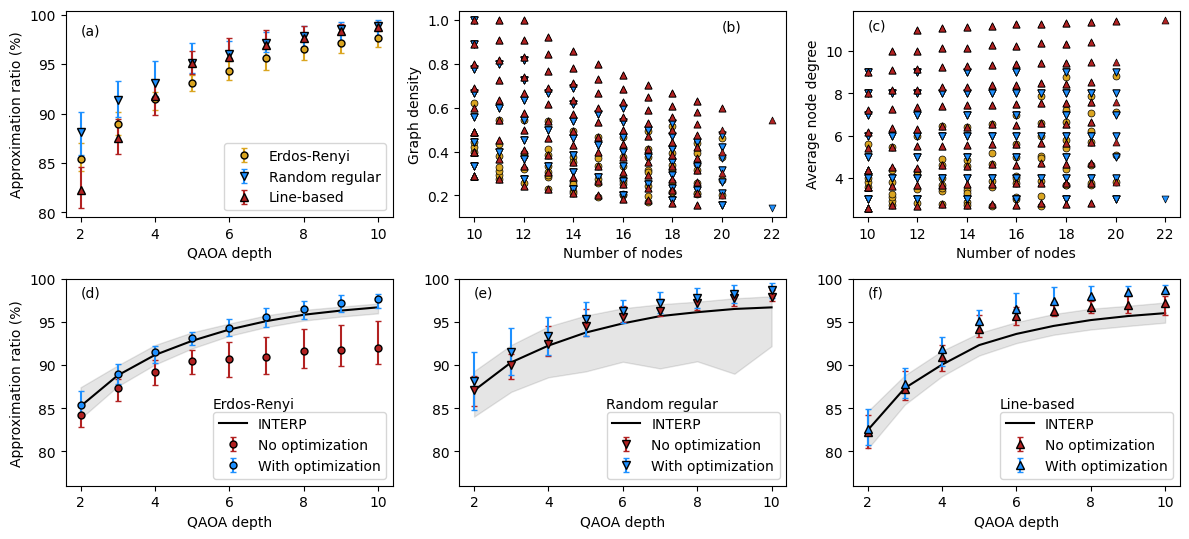

In [78]:
fig, axs = plt.subplots(2, 3, figsize=(12, 5.5))

axs = axs.flatten()

plt_opts = {"ls": "none", "ms": 5, "marker": "o", "mec": "k", "capsize": 2, "label": "Erdos-Renyi", "color": "goldenrod"}

yerrs = yerrors(er_depth, er_ps)
axs[0].errorbar(er_ps, [100 * np.median(er_depth[d]) for d in er_ps], yerr=yerrs, **plt_opts)
plt_opts = {"s": 25, "marker": "o", "ec": "k", "label": "Erdos-Renyi", "linewidth": 0.5, "color": "goldenrod"}
vals = list(properties["erdos_renyi"].values())
axs[1].scatter([v[0] for v in vals], [v[1] for v in vals], **plt_opts)
axs[2].scatter([v[0] for v in vals], [v[2] for v in vals], **plt_opts)

plt_opts = {"ls": "none", "ms": 6, "marker": "v", "mec": "k", "capsize": 2, "label": "Random regular", "color": "dodgerblue"}
yerrs = yerrors(rr_depth, rr_ps)
axs[0].errorbar(rr_ps, [100 * np.median(rr_depth[d]) for d in rr_ps], yerr=yerrs, **plt_opts)
plt_opts = {"s": 25, "marker": "v", "ec": "k", "label": "Random regular", "linewidth": 0.5, "color": "dodgerblue"}
vals = list(properties["random_regular"].values())
axs[1].scatter([v[0] for v in vals], [v[1] for v in vals], **plt_opts)
axs[2].scatter([v[0] for v in vals], [v[2] for v in vals], **plt_opts)

plt_opts = {"ls": "none", "ms": 6, "marker": "^", "mec": "k", "capsize": 2, "label": "Line-based", "color": "firebrick"}
yerrs = yerrors(lf_depth, lf_ps)
axs[0].errorbar(lf_ps, [100 * np.median(lf_depth[d]) for d in lf_ps], yerr=yerrs, **plt_opts)
plt_opts = {"s": 25, "marker": "^", "ec": "k", "label": "Line-based", "linewidth": 0.5, "color": "firebrick"}
vals = list(properties["line_to_full"].values())
axs[1].scatter([v[0] for v in vals], [v[1] for v in vals], **plt_opts)
axs[2].scatter([v[0] for v in vals], [v[2] for v in vals], **plt_opts)

axs[0].legend()
axs[0].set_xlabel("QAOA depth")
axs[0].set_ylabel("Approximation ratio (%)")
axs[3].set_ylabel("Approximation ratio (%)")
axs[1].set_xlabel("Number of nodes")
axs[1].set_ylabel("Graph density")
axs[2].set_xlabel("Number of nodes")
axs[2].set_ylabel("Average node degree")

plt_opts = {"ls": "none", "ms": 5, "marker": "o", "mec": "k", "capsize": 2, "color": "firebrick"}
axs[3].plot(i_er_ps, [100 * np.median(i_er_depth[d]) for d in i_er_ps], color="k", label="INTERP")
axs[3].fill_between(i_er_ps, [100 * np.quantile(i_er_depth[d], 0.25) for d in i_er_ps], [100 * np.quantile(i_er_depth[d], 0.75) for d in i_er_ps], color="k", alpha=0.1)
yerrs = yerrors(er_depth_no, er_ps_no)
axs[3].errorbar(er_ps_no, [100 * np.median(er_depth_no[d]) for d in er_ps_no], yerr=yerrs, **plt_opts, label="No optimization")
plt_opts = {"ls": "none", "ms": 5, "marker": "o", "mec": "k", "capsize": 2, "color": "dodgerblue"}
yerrs = yerrors(er_depth, er_ps)
axs[3].errorbar(er_ps, [100 * np.median(er_depth[d]) for d in er_ps], yerr=yerrs, **plt_opts, label="With optimization")
axs[3].text(5.55, 85, "Erdos-Renyi", horizontalalignment='left')

plt_opts = {"ls": "none", "ms": 6, "marker": "v", "mec": "k", "capsize": 2, "color": "firebrick"}
axs[4].plot(i_lf_ps, [100 * np.median(i_rr_depth[d]) for d in i_rr_ps], color="k", label="INTERP")
axs[4].fill_between(i_rr_ps, [100 * np.quantile(i_rr_depth[d], 0.25) for d in i_rr_ps], [100 * np.quantile(i_rr_depth[d], 0.75) for d in i_rr_ps], color="k", alpha=0.1)
yerrs = yerrors(rr_depth_no, rr_ps_no)
axs[4].errorbar(rr_ps_no, [100 * np.median(rr_depth_no[d]) for d in rr_ps_no], yerr=yerrs, **plt_opts, label="No optimization")
plt_opts = {"ls": "none", "ms": 6, "marker": "v", "mec": "k", "capsize": 2, "color": "dodgerblue"}
axs[4].errorbar(rr_ps, [100 * np.average(rr_depth[d]) for d in rr_ps], yerr=[100 * np.std(rr_depth[d]) for d in rr_ps], **plt_opts, label="With optimization")
#axs[4].set_title("Random regular")
axs[4].text(5.55, 85, "Random regular", horizontalalignment='left')

plt_opts = {"ls": "none", "ms": 6, "marker": "^", "mec": "k", "capsize": 2, "color": "firebrick"}
axs[5].plot(i_lf_ps, [100 * np.median(i_lf_depth[d]) for d in i_lf_ps], color="k", label="INTERP")
axs[5].fill_between(i_er_ps, [100 * np.quantile(i_lf_depth[d], 0.25) for d in i_lf_ps], [100 * np.quantile(i_lf_depth[d], 0.75) for d in i_lf_ps], color="k", alpha=0.1)
yerrs = yerrors(lf_depth_no, lf_ps_no)
axs[5].errorbar(lf_ps_no, [100 * np.average(lf_depth_no[d]) for d in lf_ps_no], yerr=yerrs, **plt_opts, label="No optimization")
plt_opts = {"ls": "none", "ms": 6, "marker": "^", "mec": "k", "capsize": 2, "color": "dodgerblue"}
yerrs = yerrors(lf_depth, lf_ps)
axs[5].errorbar(lf_ps, [100 * np.average(lf_depth[d]) for d in lf_ps], yerr=yerrs, **plt_opts, label="With optimization")
axs[5].text(5.55, 85, "Line-based", horizontalalignment='left')

for ax in axs[3:]:
    ax.set_ylim([76, 100])
    ax.legend(loc=4)
    ax.set_xlabel("QAOA depth")

axs[0].text(2, 98, "(a)")
axs[1].text(20, 0.95, "(b)")
axs[2].text(10, 11, "(c)")
axs[3].text(2, 98, "(d)")
axs[4].text(2, 98, "(e)")
axs[5].text(2, 98, "(f)")
#axs[5].set_xticks([2, 3, 4])
#axs[5].set_xticklabels(["2", "3", "4"])

for ax in [axs[1], axs[2]]:
    ax.set_xticks([10, 12, 14, 16, 18, 20, 22])
    ax.set_xticklabels([10, 12, 14, 16, 18, 20, 22])

fig.tight_layout()
fig.subplots_adjust(hspace=0.3)
    
fig.savefig("figures/20260120_fixed_angle_analysis.pdf", bbox_inches="tight")

In [79]:
print("Graph numbers with optimization")
for key, val in sv_fa_opt.items():
    print(f"Number of {key} graphs with optimization", [len(v) for v in val.values()])

Graph numbers with optimization
Number of random_regular graphs with optimization [113, 39, 358, 152, 57, 48, 362, 57, 48]
Number of erdos_renyi graphs with optimization [72, 72, 52, 39, 16, 16, 16, 16, 16]
Number of line_to_full graphs with optimization [293, 266, 95, 19, 18, 18, 18, 18, 49]


In [80]:
print("Graph numbers without optimization")
for key, val in sv_fa_no_opt.items():
    print(f"Number of {key} graphs without optimization", [len(v) for v in val.values()])

Graph numbers without optimization
Number of random_regular graphs without optimization [111, 39, 342, 147, 57, 48, 351, 55, 47]
Number of erdos_renyi graphs without optimization [72, 72, 52, 39, 16, 16, 16, 16, 16]
Number of line_to_full graphs without optimization [266, 95, 293, 47, 18, 19, 18, 18, 18]
